In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt

# Loading

In [2]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

# Additional miRNA Selection

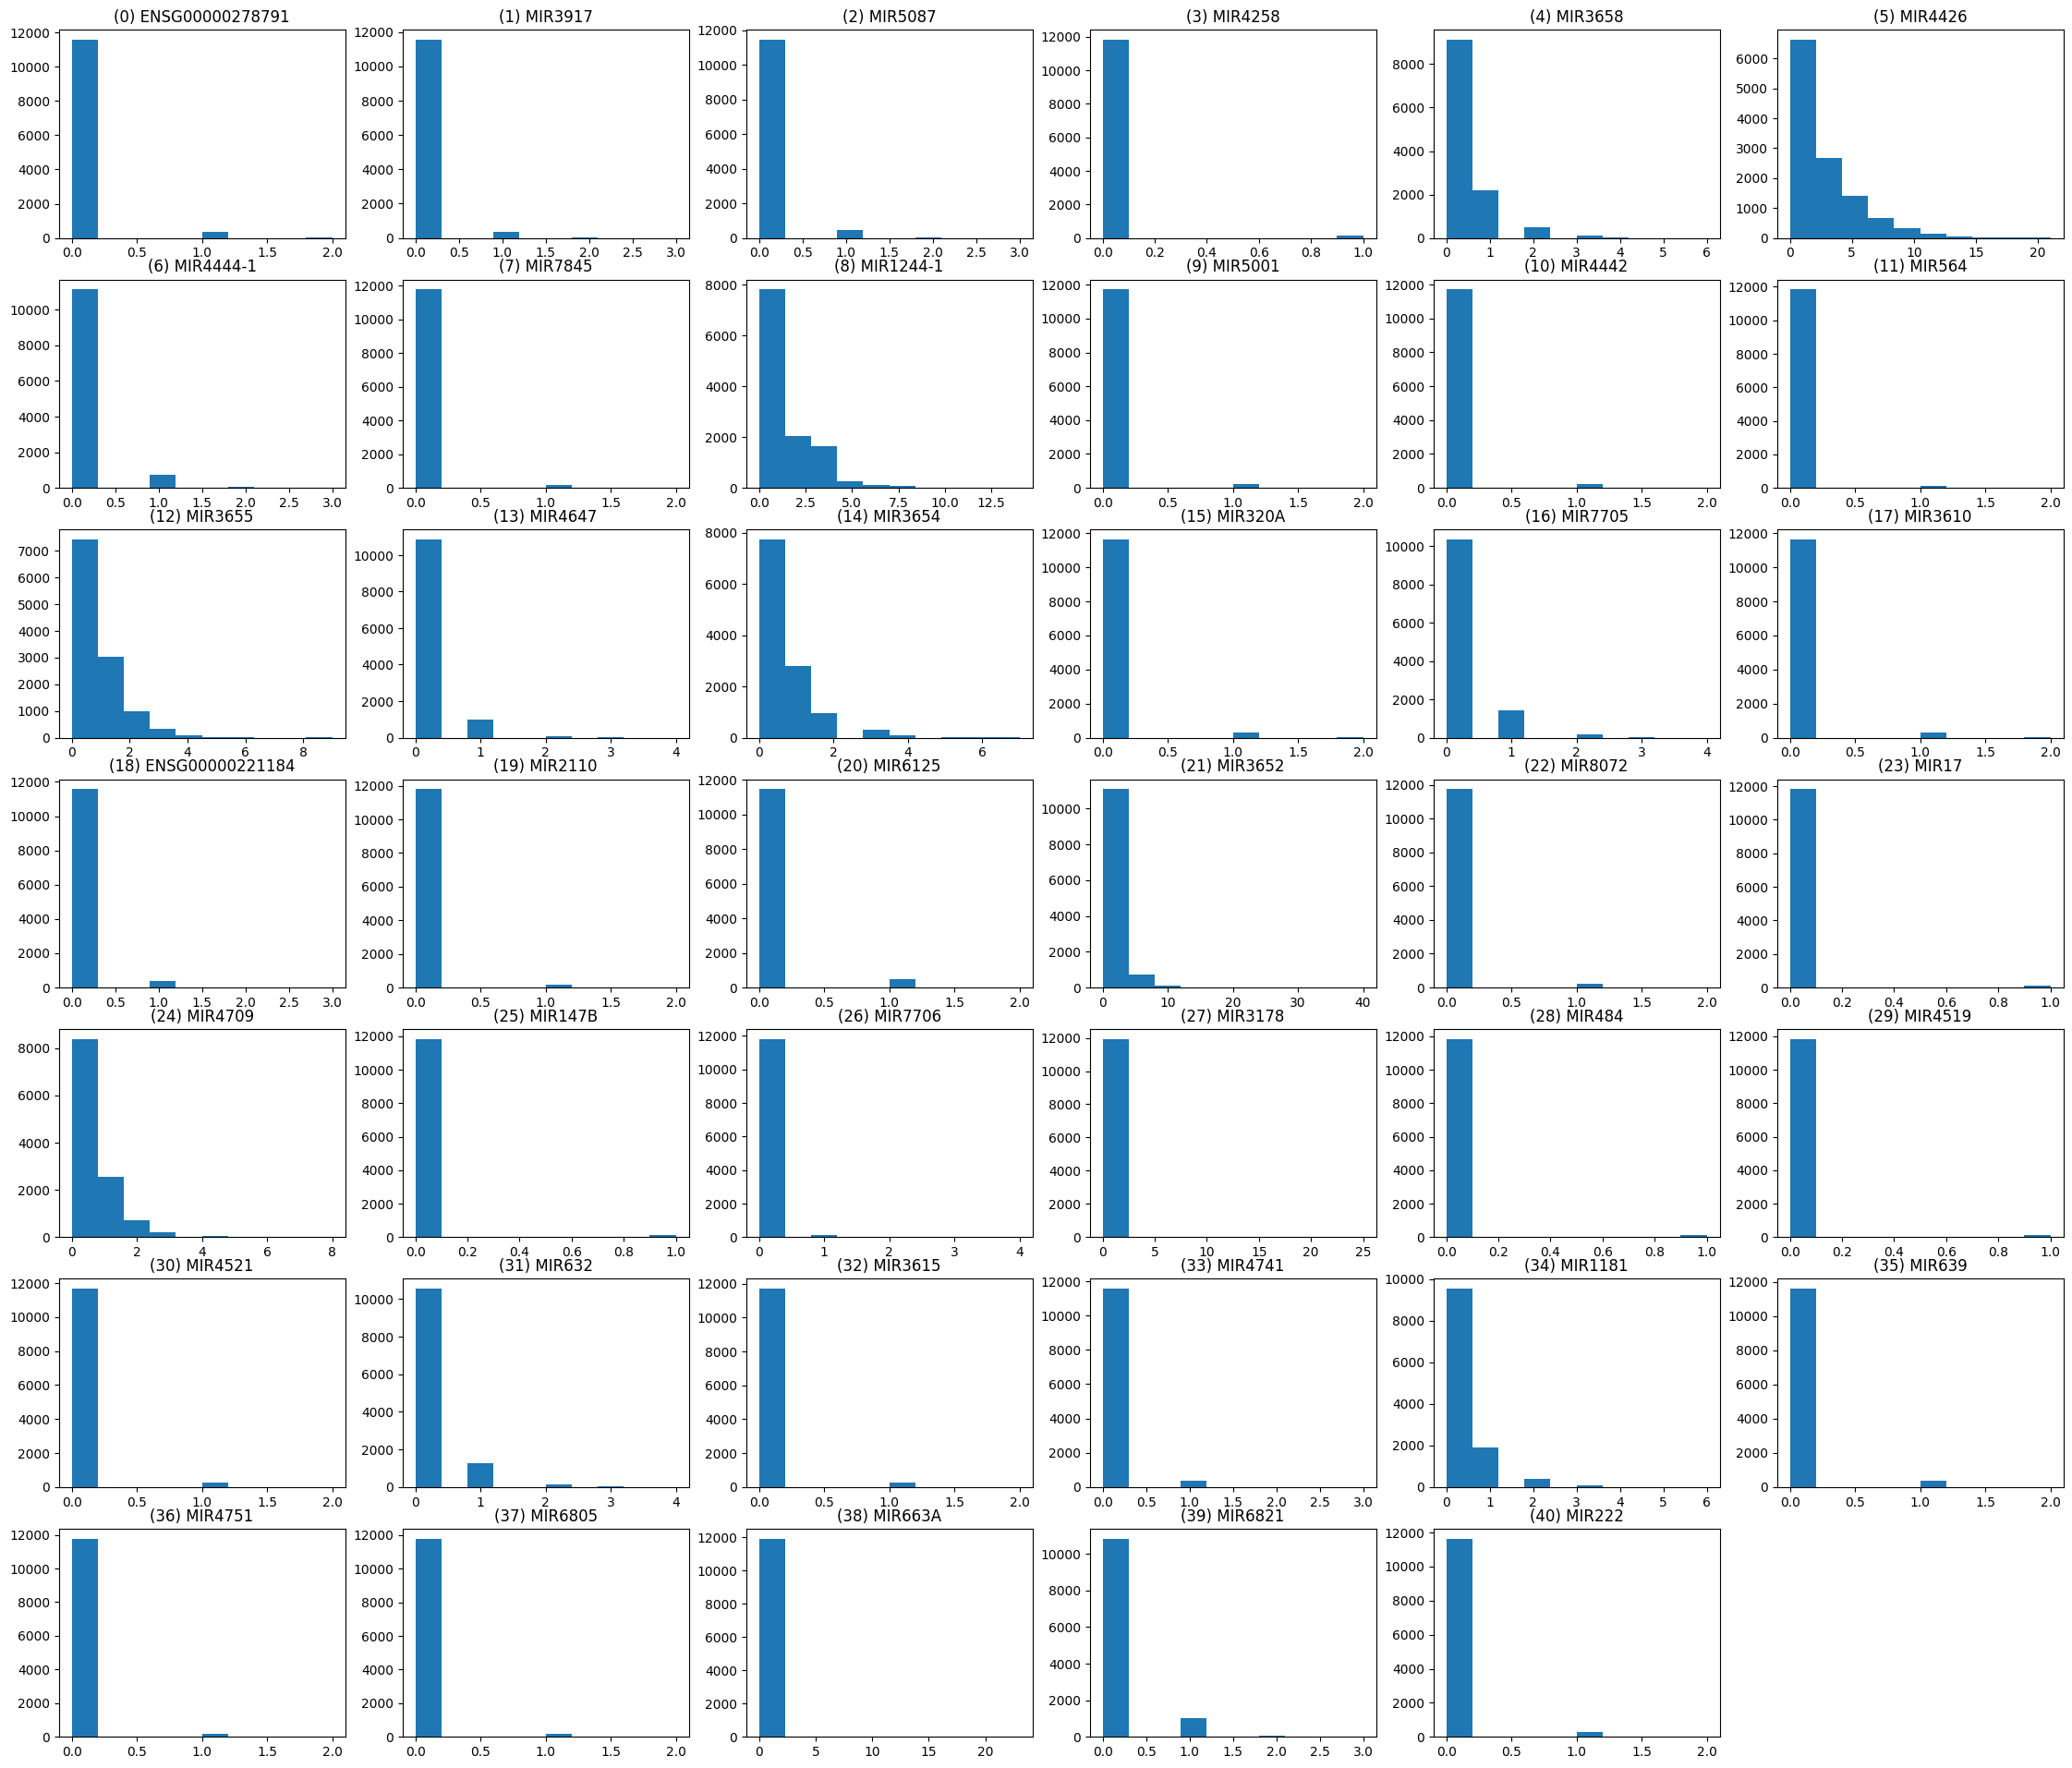

In [3]:
# miRNA distributions
M, N = 7, 6
fig, axs = plt.subplots(M, N, figsize=(7 * 4, 6 * 4))
k = 0
for i in range(M):
    for j in range(N):
        if k == 41:
            axs[i, j].axis('off')
            break
        data = adata_miRNA[:, k]
        sample = data.X.toarray()
        axs[i, j].hist(sample)
        axs[i, j].set_title(f"({k}) {data.var['GeneName'].iloc[0]}")
        k += 1
plt.show()

Many miRNA have observed counts of only {0, 1} or very few higher, giving very little information to analyse

For now restrict to miRNA with a maximum observed count of at least 3

(can easily analyse those removed and append to results)

In [4]:
# max observed count per miRNA
max_count = adata_miRNA.X.max(axis=0).toarray()

# select
count_mask = (max_count >= 3).squeeze()
miRNA_idxs = np.arange(len(count_mask))[count_mask]

# subset miRNA
adata_miRNA = adata_miRNA[:, miRNA_idxs]

# display
print(f"{sum(count_mask)} / {len(count_mask)} miRNA retained")

20 / 41 miRNA retained


# Running

In [5]:
# settings
d = 3

# get pcRNA names
pcRNA_names = adata_pcRNA.var['GeneName'].tolist()

# initialize result dataframes
#MF_ind_df = pd.DataFrame(index=pcRNA_names)
#MF_int_df = pd.DataFrame(index=pcRNA_names)
#corr_df = pd.DataFrame(index=pcRNA_names)
 
# for each miRNA
for i in range(adata_miRNA.n_vars):

    # select miRNA
    miRNA = adata_miRNA[:, i].var['GeneName'].iloc[0]

    # display progress
    print(f"{i + 1} / {adata_miRNA.n_vars}: {miRNA}")

    # initialize dataset -------------------------------------------------------
    data = SDP_miRNA.dataset.Dataset()

    # construct dataset with default: miRNA paired with all mRNA
    data.construct_dataset_adata(
        adata_miRNA[:, i],
        adata_pcRNA,
        beta
    )

    # bootstrap
    data.bootstrap(d=d)

    # OB & AL estimates: point and interval ------------------------------------
    OB_corrs, AL_corrs = SDP_miRNA.correlation.compute_correlations(data)

    # store
    corr_df[f'{miRNA}_OB'] = OB_corrs[:, 0]
    corr_df[f'{miRNA}_OB_min'] = OB_corrs[:, 1]
    corr_df[f'{miRNA}_OB_max'] = OB_corrs[:, 2]
    corr_df[f'{miRNA}_AL'] = AL_corrs[:, 0]
    corr_df[f'{miRNA}_AL_min'] = AL_corrs[:, 1]
    corr_df[f'{miRNA}_AL_max'] = AL_corrs[:, 2]

    # model free independence test ---------------------------------------------
    MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data, d=d)
    MF_ind.analyse_dataset()

    # extract results
    status = np.array([sol['status'] for sol in MF_ind.result_dict.values()])

    # store
    MF_ind_df[f'{miRNA}_status'] = status

    # select indices of interacting pairs --------------------------------------
    int_idxs = np.arange(status.size)[status == "INFEASIBLE"]

    # reduce gene queries to these
    gene_queries = [
        [[0], [int(i)]] for i in int_idxs
    ]

    # store previous total
    full_query_total = data.total_gene_queries

    # reduce dataset
    data.gene_queries = gene_queries
    data.total_gene_queries = len(gene_queries)
    data.moment_bounds = data.moment_bounds[:, int_idxs, :]

    # model free interacting test (including Hit & Run)
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data, d=d)
    MF_int.analyse_dataset()

    # Hit & Run correlations
    HAR_points, HAR_intervals = MF_int.compute_dataset_correlation()

    # Hit & Run midpoint: useful statistic
    HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

    # embedd MF int results (only on interacting pairs) into array of all pairs
    HAR_all = np.empty((full_query_total, 3)) * np.nan
    HAR_all[int_idxs, 0] = HAR_intervals[:, 0]
    HAR_all[int_idxs, 1] = HAR_intervals[:, 1]
    HAR_all[int_idxs, 2] = HAR_mid

    # store
    MF_int_df[f'{miRNA}_HAR_min'] = HAR_all[:, 0]
    MF_int_df[f'{miRNA}_HAR_max'] = HAR_all[:, 1]
    MF_int_df[f'{miRNA}_HAR_mid'] = HAR_all[:, 2]

    # write results ------------------------------------------------------------
    #MF_ind_df.to_csv(f"Results/New/independent_MF.csv") # commented out after running
    #MF_int_df.to_csv(f"Results/New/interacting_MF.csv")
    #corr_df.to_csv(f"Results/New/correlation.csv")

1 / 20: MIR3917


  1%|          | 1/104 [00:00<01:40,  1.02it/s]c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
  9%|▉         | 6/67 [00:04<00:43,  1.40it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 45%|████▍     | 30/67 [00:19<00:24,  1.54it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


...

 88%|████████▊ | 6081/6926 [02:00<00:17, 49.47it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 88%|████████▊ | 6087/6926 [02:00<00:16, 51.79it/s]

Computation failed: 'NoneType' object is not iterable


 93%|█████████▎| 6409/6926 [02:06<00:09, 52.31it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 93%|█████████▎| 6422/6926 [02:06<00:09, 53.13it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 6926/6926 [02:16<00:00, 50.77it/s]


`PerformanceWarning` by Pandas is silly, can suppress if needed using:

```{python}
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
```

# Results

In [9]:
MF_ind_df

,MIR3917_status,MIR5087_status,MIR3658_status,MIR4426_status,MIR4444-1_status,MIR1244-1_status,MIR3655_status,MIR4647_status,MIR3654_status,MIR7705_status,ENSG00000221184_status,MIR3652_status,MIR4709_status,MIR7706_status,MIR3178_status,MIR632_status,MIR4741_status,MIR1181_status,MIR663A_status,MIR6821_status
SAMD11,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE
NOC2L,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,OPTIMAL,INFEASIBLE,INFEASIBLE,INFEASIBLE
HES4,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE,INFEASIBLE
ISG15,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL
AGRN,OPTIMAL,OPTIMAL,INFEASIBLE,INFEASIBLE,OPTIMAL,INFEASIBLE,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,INFEASIBLE,OPTIMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,INFEASIBLE,INFEASIBLE,INFEASIBLE,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,INFEASIBLE
MT-ND4,OPTIMAL,OPTIMAL,INFEASIBLE,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE
MT-ND5,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,INFEASIBLE,INFEASIBLE,INFEASIBLE,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE
MT-ND6,OPTIMAL,OPTIMAL,INFEASIBLE,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,INFEASIBLE,INFEASIBLE,OPTIMAL,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL,INFEASIBLE,INFEASIBLE,INFEASIBLE,INFEASIBLE,INFEASIBLE,INFEASIBLE


In [10]:
for c in MF_ind_df.columns:
    x = (MF_ind_df[c] == "INFEASIBLE").sum()
    miRNA = c.split("_")[0]
    print(f"{miRNA} | {round(100 * x / 10307)}% | {x} / 10307")

MIR3917 | 1% | 67 / 10307
MIR5087 | 2% | 237 / 10307
MIR3658 | 19% | 2008 / 10307
MIR4426 | 23% | 2351 / 10307
MIR4444-1 | 10% | 1019 / 10307
MIR1244-1 | 21% | 2119 / 10307
MIR3655 | 9% | 947 / 10307
MIR4647 | 8% | 793 / 10307
MIR3654 | 28% | 2919 / 10307
MIR7705 | 4% | 381 / 10307
ENSG00000221184 | 7% | 737 / 10307
MIR3652 | 50% | 5132 / 10307
MIR4709 | 14% | 1443 / 10307
MIR7706 | 1% | 147 / 10307
MIR3178 | 73% | 7556 / 10307
MIR632 | 9% | 962 / 10307
MIR4741 | 2% | 248 / 10307
MIR1181 | 15% | 1571 / 10307
MIR663A | 47% | 4837 / 10307
MIR6821 | 67% | 6926 / 10307


In [ ]:
MF_int_df

,MIR3917_HAR_min,MIR3917_HAR_max,MIR3917_HAR_mid,MIR5087_HAR_min,MIR5087_HAR_max,MIR5087_HAR_mid,MIR3658_HAR_min,MIR3658_HAR_max,MIR3658_HAR_mid,MIR4426_HAR_min,...,MIR4741_HAR_mid,MIR1181_HAR_min,MIR1181_HAR_max,MIR1181_HAR_mid,MIR663A_HAR_min,MIR663A_HAR_max,MIR663A_HAR_mid,MIR6821_HAR_min,MIR6821_HAR_max,MIR6821_HAR_mid
SAMD11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.436304,-0.135199,-0.285752
NOC2L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.236998,0.439929,0.338464,-0.167510,-0.032388,-0.099949,-0.457684,-0.177056,-0.317370
HES4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.183941,-0.061661,-0.122801,-0.672205,-0.326909,-0.499557
ISG15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGRN,NaN,NaN,NaN,NaN,NaN,NaN,-0.230501,-0.049525,-0.140013,-0.327513,...,-0.123851,NaN,NaN,NaN,0.263447,0.722155,0.492801,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,-0.132205,0.001759,-0.065223,NaN,NaN,NaN,-0.275833,-0.105737,-0.190785,-0.593752,...,NaN,-0.130346,0.028047,-0.051149,0.053080,0.183688,0.118384,-0.261595,-0.094416,-0.178005
MT-ND4,NaN,NaN,NaN,NaN,NaN,NaN,-0.477885,-0.128405,-0.303145,-0.868405,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.946975,-0.444158,-0.695567
MT-ND5,-0.122292,0.010357,-0.055967,NaN,NaN,NaN,-0.290763,-0.091889,-0.191326,-0.667334,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.258590,-0.089745,-0.174168
MT-ND6,NaN,NaN,NaN,NaN,NaN,NaN,-0.357405,-0.154340,-0.255873,-0.669565,...,-0.094512,-0.123927,0.039526,-0.042201,0.117315,0.378978,0.248146,-0.289158,-0.083837,-0.186498


In [12]:
corr_df

,MIR3917_OB,MIR3917_OB_min,MIR3917_OB_max,MIR3917_AL,MIR3917_AL_min,MIR3917_AL_max,MIR5087_OB,MIR5087_OB_min,MIR5087_OB_max,MIR5087_AL,...,MIR663A_OB_max,MIR663A_AL,MIR663A_AL_min,MIR663A_AL_max,MIR6821_OB,MIR6821_OB_min,MIR6821_OB_max,MIR6821_AL,MIR6821_AL_min,MIR6821_AL_max
SAMD11,0.070115,0.045391,0.095099,0.031166,-0.049276,0.111303,0.074999,0.053718,0.096711,0.025825,...,0.127098,0.107177,0.052645,0.178280,0.040566,0.022142,0.059329,-0.213120,-0.275619,-0.149656
NOC2L,0.099921,0.077650,0.123293,0.100177,0.033116,0.170892,0.101662,0.079076,0.126175,0.079485,...,0.016296,-0.080590,-0.110220,-0.053503,0.043167,0.024235,0.062357,-0.231816,-0.292045,-0.169025
HES4,0.065039,0.044693,0.086450,-0.032836,-0.113039,0.052644,0.088331,0.064334,0.110565,0.024735,...,0.008824,-0.114246,-0.171095,-0.070827,0.027640,0.009348,0.047168,-0.377455,-0.456467,-0.294471
ISG15,0.040870,0.020131,0.060875,0.028475,-0.038390,0.096240,0.026506,0.006137,0.048957,-0.028428,...,0.037513,-0.007492,-0.065798,0.038782,0.024891,0.004194,0.045466,-0.105664,-0.175279,-0.034603
AGRN,0.044270,0.017213,0.075610,0.060068,-0.019563,0.143756,0.035208,0.012550,0.060684,0.026496,...,0.441260,0.511604,0.309138,0.676453,0.008368,-0.009864,0.029457,-0.089000,-0.150862,-0.023773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,0.035695,0.020120,0.054094,-0.042211,-0.077991,-0.010145,0.069018,0.041459,0.107055,0.022363,...,0.190966,0.141246,0.081494,0.248181,0.028159,0.011972,0.045940,-0.154637,-0.217876,-0.111258
MT-ND4,0.077179,0.057497,0.097996,-0.080078,-0.150941,-0.007225,0.140655,0.116813,0.163718,0.103611,...,0.126931,0.042600,-0.021992,0.135713,0.043921,0.025617,0.063356,-0.464712,-0.550122,-0.386471
MT-ND5,0.047603,0.032159,0.071123,-0.029271,-0.062012,0.003656,0.095728,0.064651,0.142569,0.060633,...,0.128761,0.060598,0.023811,0.126436,0.031338,0.015764,0.052533,-0.167117,-0.243916,-0.118758
MT-ND6,0.043736,0.025794,0.065880,-0.031367,-0.071857,0.019004,0.060502,0.040581,0.082943,-0.003342,...,0.268019,0.236437,0.144502,0.359367,0.029528,0.010903,0.049513,-0.171381,-0.232495,-0.112705


# Old

## Running

### 5

In [194]:
#%run -i independent_MF_script.py --array_index 5

100%|██████████| 10307/10307 [06:19<00:00, 27.17it/s]


In [195]:
#%run -i interacting_MF_script.py --array_index 5

  1%|          | 17/2406 [00:12<29:12,  1.36it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


  4%|▍         | 106/2406 [01:16<28:02,  1.37it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 10%|█         | 251/2406 [03:00<25:36,  1.40it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


...

 88%|████████▊ | 2118/2406 [25:03<03:48,  1.26it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 92%|█████████▏| 2212/2406 [26:19<02:38,  1.23it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 2406/2406 [28:59<00:00,  1.38it/s]


In [196]:
#%run -i birth_death_script.py --array_index 5

100%|██████████| 2406/2406 [02:29<00:00, 16.05it/s]


In [197]:
#%run -i telegraph_script.py --array_index 5

100%|██████████| 1168/1168 [1:34:09<00:00,  4.84s/it] 


In [198]:
#%run -i correlation_script.py --array_index 5

  1%|▏         | 134/10307 [00:33<41:49,  4.05it/s]c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
100%|██████████| 10307/10307 [40:11<00:00,  4.27it/s]


#### d = 2

In [ ]:
#%run -i independent_MF_script.py --array_index 5 --d 2

100%|██████████| 10307/10307 [04:12<00:00, 40.76it/s]


In [ ]:
#%run -i interacting_MF_script.py --array_index 5 --d 2

  4%|▍         | 101/2247 [01:16<24:07,  1.48it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 10%|█         | 234/2247 [02:47<23:42,  1.42it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 28%|██▊       | 636/2247 [07:24<18:17,  1.47it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


...

 79%|███████▊  | 1768/2247 [20:15<05:17,  1.51it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 92%|█████████▏| 2073/2247 [23:38<02:00,  1.44it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 2247/2247 [25:34<00:00,  1.46it/s]


In [ ]:
#%run -i birth_death_script.py --array_index 5 --d 2

100%|██████████| 2247/2247 [01:24<00:00, 26.69it/s]


In [ ]:
#%run -i telegraph_script.py --array_index 5 --d 2

100%|██████████| 5/5 [00:00<00:00,  6.30it/s]


### 12

In [42]:
#%run -i independent_MF_script.py --array_index 12

100%|██████████| 10307/10307 [06:40<00:00, 25.71it/s]


In [56]:
#%run -i interacting_MF_script.py --array_index 12

  4%|▍         | 41/960 [00:27<10:04,  1.52it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 11%|█         | 103/960 [01:09<09:46,  1.46it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 30%|██▉       | 284/960 [03:14<07:44,  1.45it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


...

 89%|████████▊ | 850/960 [09:43<01:14,  1.47it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 92%|█████████▎| 888/960 [10:09<00:49,  1.46it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 960/960 [10:58<00:00,  1.46it/s]


In [44]:
#%run -i birth_death_script.py --array_index 12

100%|██████████| 960/960 [02:20<00:00,  6.83it/s]


In [45]:
#%run -i telegraph_script.py --array_index 12

100%|██████████| 403/403 [35:16<00:00,  5.25s/it]  


In [59]:
#%run -i correlation_script.py --array_index 12

  1%|▏         | 134/10307 [00:33<41:41,  4.07it/s]c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
100%|██████████| 10307/10307 [44:48<00:00,  3.83it/s]


### 40

In [ ]:
#%run -i independent_MF_script.py --array_index 40

100%|██████████| 10307/10307 [06:31<00:00, 26.31it/s]


In [ ]:
#%run -i interacting_MF_script.py --array_index 40

  5%|▌         | 147/2937 [02:06<39:40,  1.17it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 29%|██▊       | 840/2937 [12:36<29:07,  1.20it/s]  Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 77%|███████▋  | 2275/2937 [32:06<08:01,  1.37it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


...

 88%|████████▊ | 2598/2937 [35:59<04:05,  1.38it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


 93%|█████████▎| 2740/2937 [37:40<02:23,  1.37it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_interaction_inference\optimization_MOSEK.py", line 117, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 2937/2937 [40:02<00:00,  1.22it/s]


In [ ]:
#%run -i birth_death_script.py --array_index 40

100%|██████████| 2937/2937 [02:37<00:00, 18.65it/s]


In [ ]:
#%run -i telegraph_script.py --array_index 40

100%|██████████| 6/6 [01:03<00:00, 10.59s/it]


In [ ]:
#%run -i correlation_script.py --array_index 40

  1%|▏         | 134/10307 [00:33<41:27,  4.09it/s]c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
100%|██████████| 10307/10307 [42:27<00:00,  4.05it/s]


### All fano factors

In [ ]:
#%run -i fano_script.py --RNA {"miRNA"}

100%|██████████| 41/41 [00:06<00:00,  6.47it/s]


In [ ]:
#%run -i fano_script.py --RNA {"pcRNA"}

  1%|▏         | 134/10307 [00:20<24:51,  6.82it/s]c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
100%|██████████| 10307/10307 [26:05<00:00,  6.58it/s]


## Results

In [199]:
ind_MF_5_df_NB = pd.read_csv("Results/ind_MF_5.csv", index_col=0)
int_MF_5_df_NB = pd.read_csv("Results/int_MF_5.csv", index_col=0)
BD_5_df_NB = pd.read_csv("Results/BD_5.csv", index_col=0)
TE_5_df_NB = pd.read_csv("Results/TE_5.csv", index_col=0)
corr_5_df_NB = pd.read_csv("Results/corr_5.csv", index_col=0)

In [200]:
ind_MF_5_df_NB.value_counts()

MIR4426_d3_c95_status
OPTIMAL                  7901
INFEASIBLE               2406
Name: count, dtype: int64

In [201]:
BD_5_df_NB.value_counts()

MIR4426_d3_c95_status
OPTIMAL                  1238
INFEASIBLE               1168
Name: count, dtype: int64

In [202]:
TE_5_df_NB.value_counts()

MIR4426_d3_c95_status
OPTIMAL                  905
CUT_LIMIT                132
TIME_LIMIT               131
Name: count, dtype: int64

In [203]:
int_MF_5_df_NB.head()

,MIR4426_d3_N1000_c95_mc95_HAR_corr_min,MIR4426_d3_N1000_c95_mc95_HAR_corr_max,MIR4426_d3_N1000_c95_mc95_HAR_fano_1_min,MIR4426_d3_N1000_c95_mc95_HAR_fano_1_max,MIR4426_d3_N1000_c95_mc95_HAR_fano_2_min,MIR4426_d3_N1000_c95_mc95_HAR_fano_2_max
AGRN,-0.324491,-0.030603,1.315981,2.673457,2.013168,3.022978
C1orf159,-0.459545,-0.093998,1.343368,2.264322,1.954147,3.067319
AURKAIP1,0.223340,0.635430,1.976307,3.681500,1.680268,3.276070
SSU72,0.294692,0.640794,3.452965,5.047554,1.607152,3.144843
C1orf174,-0.680688,-0.110568,0.730865,1.388449,1.784301,2.998248


In [204]:
corr_5_df_NB.head()

,MIR4426_c95_OB,MIR4426_c95_OB_min,MIR4426_c95_OB_max,MIR4426_c95_AL,MIR4426_c95_AL_min,MIR4426_c95_AL_max
SAMD11,0.345811,0.326593,0.365138,0.004603,-0.076213,0.077329
NOC2L,0.452580,0.435490,0.469617,0.218497,0.154220,0.277865
HES4,0.394713,0.375514,0.413158,-0.097323,-0.189884,-0.009235
ISG15,0.160396,0.140268,0.180830,-0.081842,-0.156274,-0.006004
AGRN,0.080173,0.057103,0.103960,-0.144254,-0.205801,-0.079479


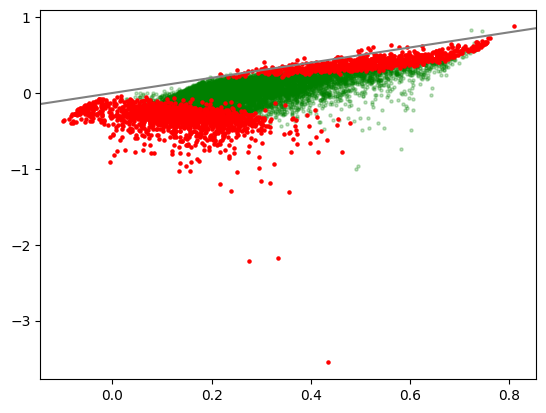

In [205]:
mask = (ind_MF_5_df_NB == "INFEASIBLE")
plt.scatter(
    corr_5_df_NB['MIR4426_c95_OB'][~mask.values.squeeze()],
    corr_5_df_NB['MIR4426_c95_AL'][~mask.values.squeeze()],
    color="green",
    s=5,
    alpha=0.25
)
plt.scatter(
    corr_5_df_NB['MIR4426_c95_OB'][mask.values.squeeze()],
    corr_5_df_NB['MIR4426_c95_AL'][mask.values.squeeze()],
    color="red",
    s=5
)
plt.axline([0, 0], [0.1, 0.1], color="grey")

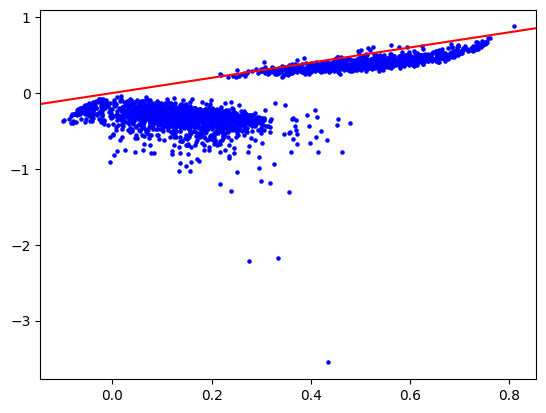

In [206]:
mask = (ind_MF_5_df_NB == "INFEASIBLE")
plt.scatter(
    corr_5_df_NB['MIR4426_c95_OB'][mask.values.squeeze()],
    corr_5_df_NB['MIR4426_c95_AL'][mask.values.squeeze()],
    color="blue",
    s=5
)
plt.axline([0, 0], [0.1, 0.1], color="red")

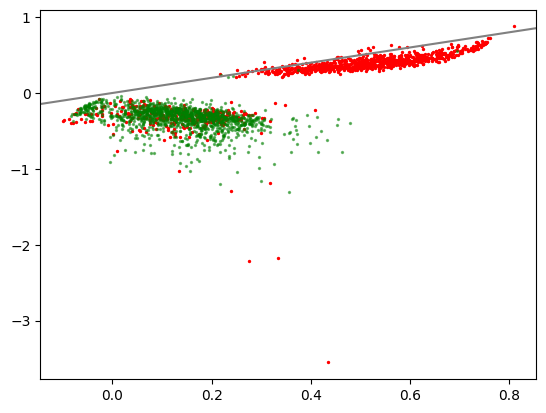

In [207]:
mask_MF = (ind_MF_5_df_NB == "INFEASIBLE")
mask_BD = (BD_5_df_NB == "INFEASIBLE")
plt.scatter(
    corr_5_df_NB['MIR4426_c95_OB'][mask_MF.values.squeeze()][mask_BD.values.squeeze()],
    corr_5_df_NB['MIR4426_c95_AL'][mask_MF.values.squeeze()][mask_BD.values.squeeze()],
    color="red",
    s=2,
    alpha=1
)
plt.scatter(
    corr_5_df_NB['MIR4426_c95_OB'][mask_MF.values.squeeze()][~mask_BD.values.squeeze()],
    corr_5_df_NB['MIR4426_c95_AL'][mask_MF.values.squeeze()][~mask_BD.values.squeeze()],
    color="green",
    s=2,
    alpha=0.5
)
plt.axline([0, 0], [0.1, 0.1], color="grey")

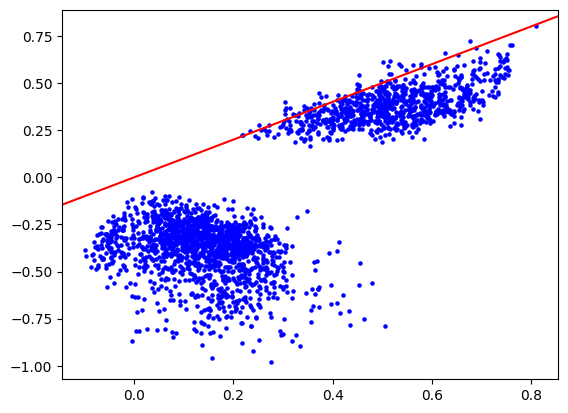

In [208]:
mask = (ind_MF_5_df_NB == "INFEASIBLE")
corr = corr_5_df_NB['MIR4426_c95_OB'][mask.values.squeeze()]
lb = int_MF_5_df_NB['MIR4426_d3_N1000_c95_mc95_HAR_corr_min']
ub = int_MF_5_df_NB['MIR4426_d3_N1000_c95_mc95_HAR_corr_max']
mid = (lb + ub) / 2
plt.scatter(
    corr,
    mid,
    color="blue",
    s=5
)
plt.axline([0, 0], [0.1, 0.1], color="red")

In [5]:
ind_MF_12_df_NB = pd.read_csv("Results/ind_MF_12.csv", index_col=0)
int_MF_12_df_NB = pd.read_csv("Results/int_MF_12.csv", index_col=0)
BD_12_df_NB = pd.read_csv("Results/BD_12.csv", index_col=0)
TE_12_df_NB = pd.read_csv("Results/TE_12.csv", index_col=0)
corr_12_df_NB = pd.read_csv("Results/corr_12.csv", index_col=0)

In [48]:
ind_MF_12_df_NB.value_counts()

MIR3655_d3_c95_status
OPTIMAL                  9347
INFEASIBLE                960
Name: count, dtype: int64

In [49]:
BD_12_df_NB.value_counts()

MIR3655_d3_c95_status
OPTIMAL                  555
INFEASIBLE               403
TIME_LIMIT                 2
Name: count, dtype: int64

In [51]:
TE_12_df_NB.value_counts()

MIR3655_d3_c95_status
OPTIMAL                  302
TIME_LIMIT                52
CUT_LIMIT                 49
Name: count, dtype: int64

In [58]:
int_MF_12_df_NB.head()

,MIR3655_d3_N1000_c95_mc95_HAR_corr_min,MIR3655_d3_N1000_c95_mc95_HAR_corr_max,MIR3655_d3_N1000_c95_mc95_HAR_fano_1_min,MIR3655_d3_N1000_c95_mc95_HAR_fano_1_max,MIR3655_d3_N1000_c95_mc95_HAR_fano_2_min,MIR3655_d3_N1000_c95_mc95_HAR_fano_2_max
PLA2G5,-0.430491,-0.175414,0.768565,1.665580,1.123157,1.675196
CDC42,-0.997791,-0.819257,0.052148,0.078023,1.635317,1.755122
KDM1A,0.126151,0.432805,3.068621,4.135684,0.944908,1.855730
HNRNPR,0.229741,0.559782,5.541540,7.723431,0.910166,1.884431
GRHL3,-0.270089,-0.171637,13.353904,18.084793,1.064924,1.790514


In [61]:
corr_12_df_NB.head()

,MIR3655_c95_OB,MIR3655_c95_OB_min,MIR3655_c95_OB_max,MIR3655_c95_AL,MIR3655_c95_AL_min,MIR3655_c95_AL_max
SAMD11,0.184508,0.164523,0.205049,-0.096449,-0.172847,-0.027888
NOC2L,0.279575,0.258293,0.299267,0.126191,0.060931,0.192077
HES4,0.211026,0.191010,0.231302,-0.185197,-0.275395,-0.109454
ISG15,0.099896,0.080443,0.122455,-0.048466,-0.115289,0.021745
AGRN,0.055800,0.036085,0.075815,-0.069979,-0.125592,-0.011113


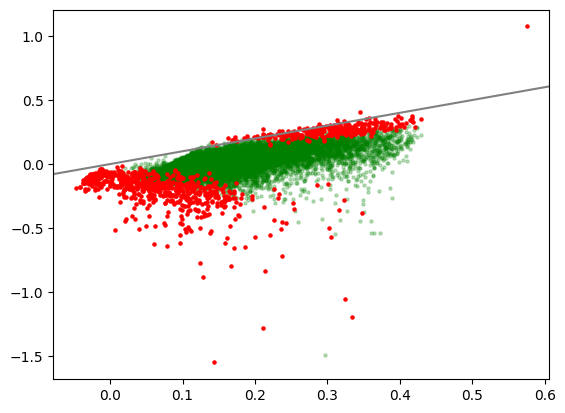

In [169]:
mask = (ind_MF_12_df_NB == "INFEASIBLE")
plt.scatter(
    corr_12_df_NB['MIR3655_c95_OB'][~mask.values.squeeze()],
    corr_12_df_NB['MIR3655_c95_AL'][~mask.values.squeeze()],
    color="green",
    s=5,
    alpha=0.25
)
plt.scatter(
    corr_12_df_NB['MIR3655_c95_OB'][mask.values.squeeze()],
    corr_12_df_NB['MIR3655_c95_AL'][mask.values.squeeze()],
    color="red",
    s=5
)
plt.axline([0, 0], [0.1, 0.1], color="grey")

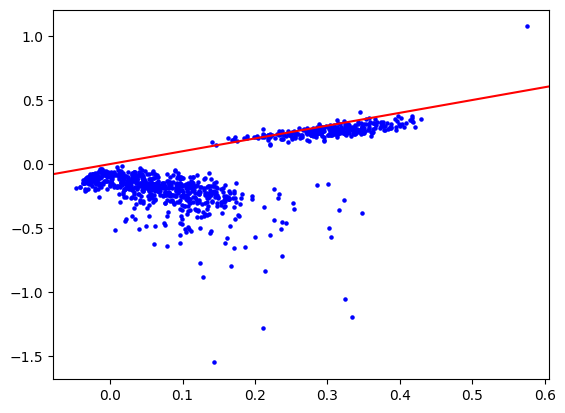

In [83]:
mask = (ind_MF_12_df_NB == "INFEASIBLE")
plt.scatter(
    corr_12_df_NB['MIR3655_c95_OB'][mask.values.squeeze()],
    corr_12_df_NB['MIR3655_c95_AL'][mask.values.squeeze()],
    color="blue",
    s=5
)
plt.axline([0, 0], [0.1, 0.1], color="red")

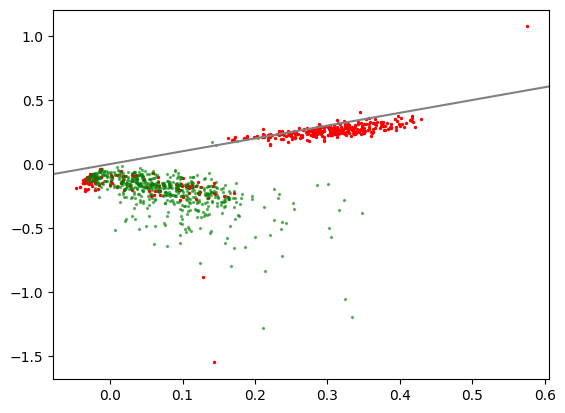

In [97]:
mask_MF = (ind_MF_12_df_NB == "INFEASIBLE")
mask_BD = (BD_12_df_NB == "INFEASIBLE")
plt.scatter(
    corr_12_df_NB['MIR3655_c95_OB'][mask_MF.values.squeeze()][mask_BD.values.squeeze()],
    corr_12_df_NB['MIR3655_c95_AL'][mask_MF.values.squeeze()][mask_BD.values.squeeze()],
    color="red",
    s=2,
    alpha=1
)
plt.scatter(
    corr_12_df_NB['MIR3655_c95_OB'][mask_MF.values.squeeze()][~mask_BD.values.squeeze()],
    corr_12_df_NB['MIR3655_c95_AL'][mask_MF.values.squeeze()][~mask_BD.values.squeeze()],
    color="green",
    s=2,
    alpha=0.5
)
plt.axline([0, 0], [0.1, 0.1], color="grey")

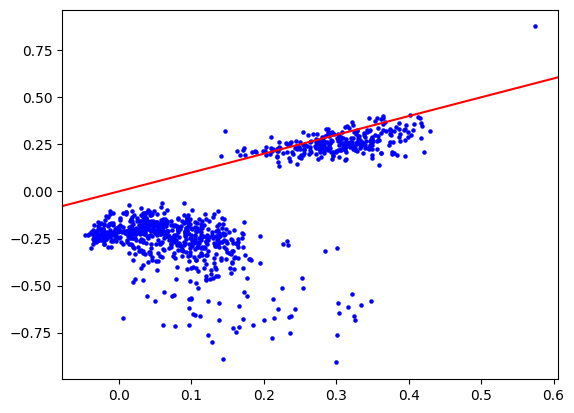

In [104]:
mask = (ind_MF_12_df_NB == "INFEASIBLE")
corr = corr_12_df_NB['MIR3655_c95_OB'][mask.values.squeeze()]
lb = int_MF_12_df_NB['MIR3655_d3_N1000_c95_mc95_HAR_corr_min']
ub = int_MF_12_df_NB['MIR3655_d3_N1000_c95_mc95_HAR_corr_max']
mid = (lb + ub) / 2
plt.scatter(
    corr,
    mid,
    color="blue",
    s=5
)
plt.axline([0, 0], [0.1, 0.1], color="red")

- positive recovered correlation group in interacting pairs
    - see for both AL and HAR midpoint
- could be due to underestimate of capture mean?
    - chose 0.2 as 0.3 gave too many 1 values

In [100]:
ind_MF_40_df_NB = pd.read_csv("Results/ind_MF_40.csv", index_col=0)
int_MF_40_df_NB = pd.read_csv("Results/int_MF_40.csv", index_col=0)
BD_40_df_NB = pd.read_csv("Results/BD_40.csv", index_col=0)
TE_40_df_NB = pd.read_csv("Results/TE_40.csv", index_col=0)
corr_40_df_NB = pd.read_csv("Results/corr_40.csv", index_col=0)

In [101]:
ind_MF_40_df_NB.value_counts()

MIR222_d3_c95_status
OPTIMAL                 7370
INFEASIBLE              2937
Name: count, dtype: int64

In [102]:
BD_40_df_NB.value_counts()

MIR222_d3_c95_status
OPTIMAL                 2931
INFEASIBLE                 6
Name: count, dtype: int64

In [103]:
TE_40_df_NB.value_counts()

MIR222_d3_c95_status
INFEASIBLE              4
TIME_LIMIT              2
Name: count, dtype: int64

In [104]:
int_MF_40_df_NB.head()

,MIR222_d3_N1000_c95_mc95_HAR_corr_min,MIR222_d3_N1000_c95_mc95_HAR_corr_max,MIR222_d3_N1000_c95_mc95_HAR_fano_1_min,MIR222_d3_N1000_c95_mc95_HAR_fano_1_max,MIR222_d3_N1000_c95_mc95_HAR_fano_2_min,MIR222_d3_N1000_c95_mc95_HAR_fano_2_max
NOC2L,-0.381305,-0.049338,2.094234,2.709347,0.391432,1.144489
MRPL20,-0.721372,-0.212080,4.216672,5.518056,0.329306,1.215624
ATAD3A,-0.349548,-0.051919,1.510098,2.067909,0.448641,1.116570
SSU72,-0.505838,-0.064832,3.383183,4.738163,0.386859,1.141853
GNB1,-0.503275,-0.126036,3.154561,3.949965,0.397216,1.136004


In [105]:
corr_40_df_NB.head()

,MIR222_c95_OB,MIR222_c95_OB_min,MIR222_c95_OB_max,MIR222_c95_AL,MIR222_c95_AL_min,MIR222_c95_AL_max
SAMD11,0.014607,-0.004649,0.037778,-0.134523,-0.203812,-0.054368
NOC2L,0.015813,-0.003457,0.034966,-0.143695,-0.208718,-0.082600
HES4,0.032494,0.011655,0.054349,-0.129253,-0.219392,-0.045870
ISG15,0.026925,0.005755,0.048461,-0.006943,-0.083653,0.070756
AGRN,0.003904,-0.016173,0.025285,-0.048263,-0.108641,0.019354


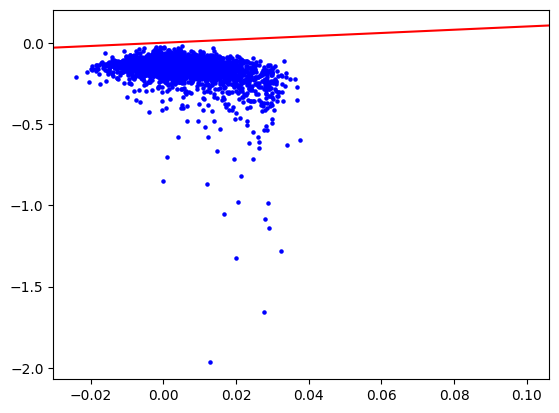

In [106]:
mask = (ind_MF_40_df_NB == "INFEASIBLE")
plt.scatter(
    corr_40_df_NB['MIR222_c95_OB'][mask.values.squeeze()],
    corr_40_df_NB['MIR222_c95_AL'][mask.values.squeeze()],
    color="blue",
    s=5
)
plt.axline([0, 0], [0.1, 0.1], color="red")

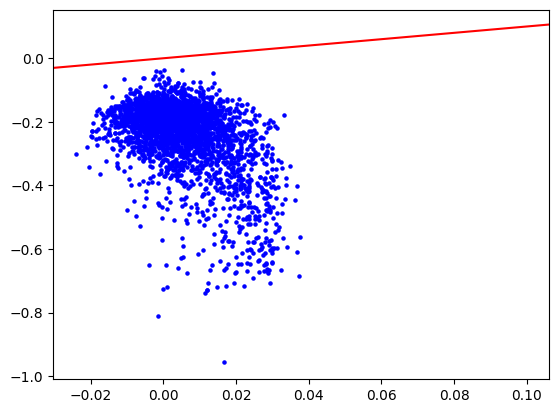

In [107]:
mask = (ind_MF_40_df_NB == "INFEASIBLE")
corr = corr_40_df_NB['MIR222_c95_OB'][mask.values.squeeze()]
lb = int_MF_40_df_NB['MIR222_d3_N1000_c95_mc95_HAR_corr_min']
ub = int_MF_40_df_NB['MIR222_d3_N1000_c95_mc95_HAR_corr_max']
mid = (lb + ub) / 2
plt.scatter(
    corr,
    mid,
    color="blue",
    s=5
)
plt.axline([0, 0], [0.1, 0.1], color="red")

# Appendix

## miRNA distributions

In [9]:
import anndata as ad
import matplotlib.pyplot as plt

In [4]:
# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

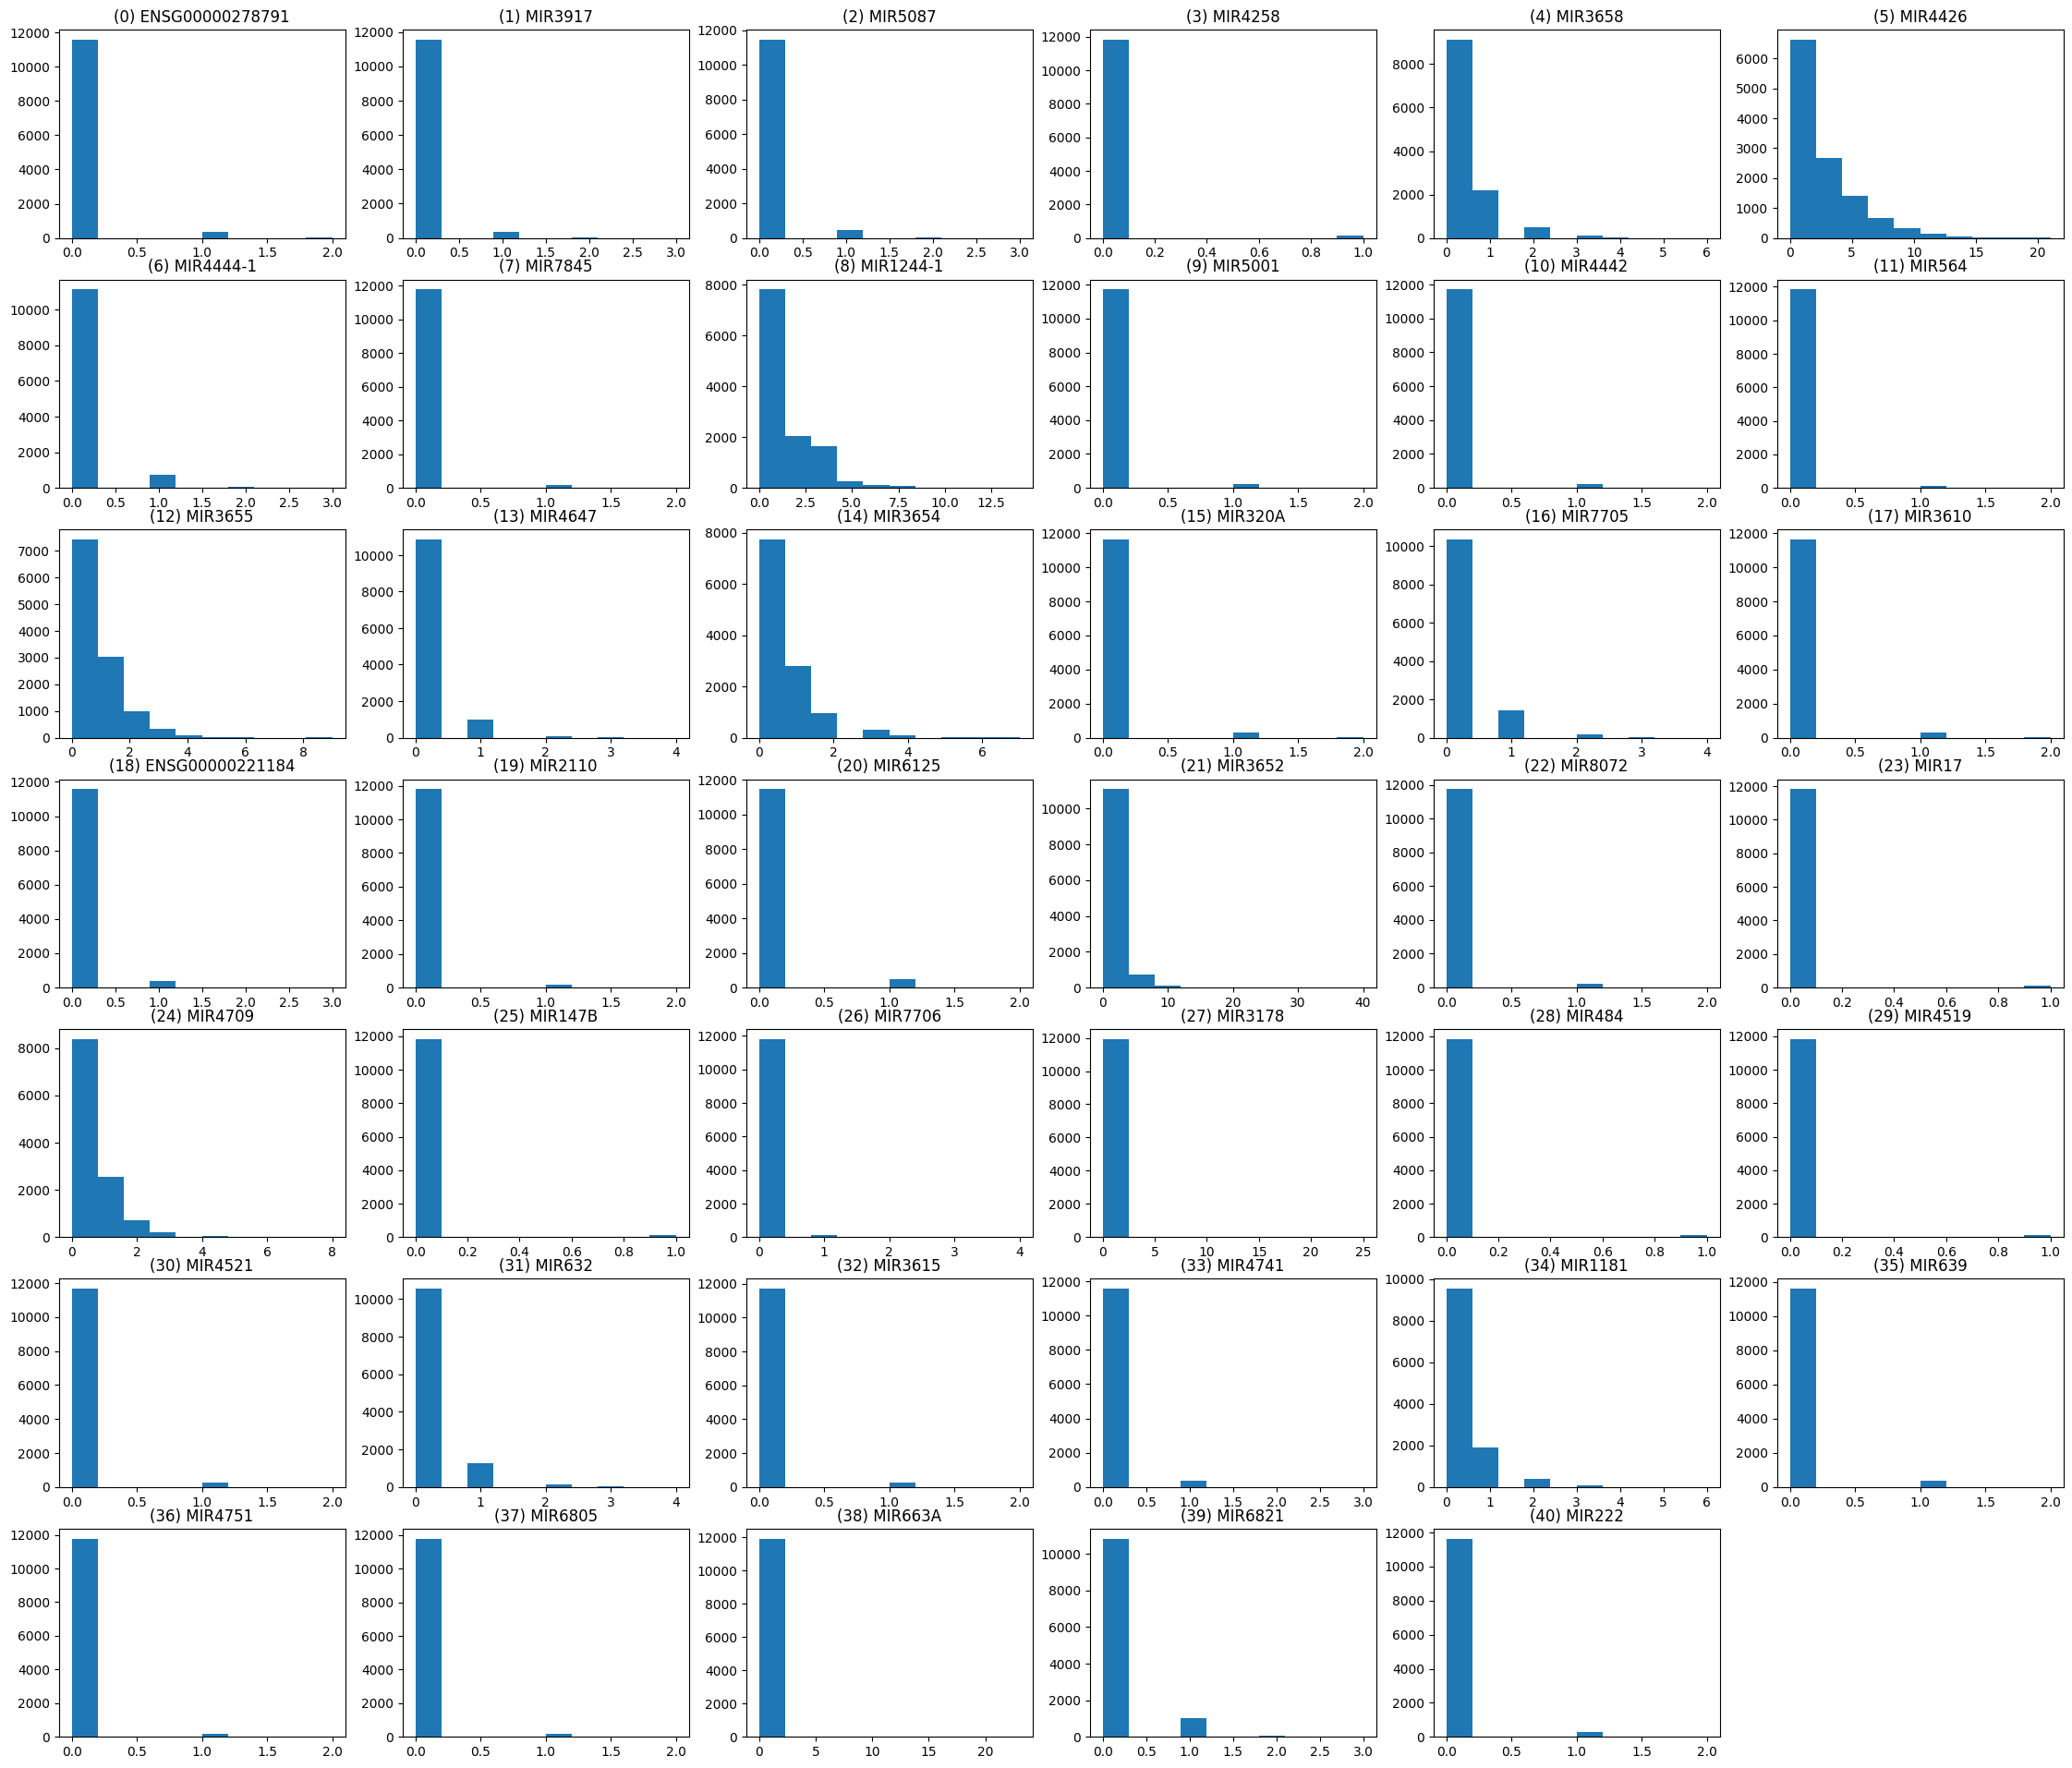

In [29]:
M, N = 7, 6
fig, axs = plt.subplots(M, N, figsize=(7 * 4, 6 * 4))
k = 0
for i in range(M):
    for j in range(N):
        if k == 41:
            axs[i, j].axis('off')
            break
        data = adata_miRNA[:, k]
        sample = data.X.toarray()
        axs[i, j].hist(sample)
        axs[i, j].set_title(f"({k}) {data.var['GeneName'].iloc[0]}")
        k += 1
plt.show()

## mRNA - mRNA correlations

In [49]:
import anndata as ad
import numpy as np
from SDP_interaction_inference.dataset import SparseDataset
import tqdm
import scipy
import matplotlib.pyplot as plt

In [50]:
rng = np.random.default_rng(423)

In [51]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

In [78]:
def correlation_bootstrap_sample(sample, beta, confidence=None, resamples=None):

    # get sample size
    n = sample.shape[0]

    # get bootstrap size: default to 1000
    if resamples is None:
        resamples = 1000
    # confidence level: default to 95%
    if confidence is None:
        confidence = 0.95

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # capture moments
    E_beta = np.mean(beta)
    E_beta2 = np.mean(beta**2)

    # compute correlations
    estimates = np.zeros(resamples)

    b1 = boot[:, :, 0]
    b2 = boot[:, :, 1]

    # OB moments
    E_xy_OB = np.mean(b1 * b2, axis=1)
    E_x_OB = np.mean(b1, axis=1)
    E_y_OB = np.mean(b2, axis=1)
    E_x2_OB = np.mean(b1**2, axis=1)
    E_y2_OB = np.mean(b2**2, axis=1)

    # OG moments
    E_xy_OG = E_xy_OB / E_beta2
    E_x_OG = E_x_OB / E_beta
    E_y_OG = E_y_OB / E_beta
    E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
    E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

    varx_OG = E_x2_OG - E_x_OG**2
    vary_OG = E_y2_OG - E_y_OG**2

    mask = (varx_OG > 0.0) & (vary_OG > 0.0)
    estimates[~mask] = np.nan
    estimates[mask] = (E_xy_OG[mask] - E_x_OG[mask]*E_y_OG[mask]) / (np.sqrt(varx_OG[mask]) * np.sqrt(vary_OG[mask]))

    # take quantiles
    alpha = 1 - confidence
    interval = np.nanquantile(estimates, [(alpha / 2), 1 - (alpha / 2)])

    # compute point estimate from original sample
    b1 = sample[:, 0]
    b2 = sample[:, 1]

    # OB moments
    E_xy_OB = np.mean(b1 * b2)
    E_x_OB = np.mean(b1)
    E_y_OB = np.mean(b2)
    E_x2_OB = np.mean(b1**2)
    E_y2_OB = np.mean(b2**2)

    # OG moments
    E_xy_OG = E_xy_OB / E_beta2
    E_x_OG = E_x_OB / E_beta
    E_y_OG = E_y_OB / E_beta
    E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
    E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

    varx_OG = E_x2_OG - E_x_OG**2
    vary_OG = E_y2_OG - E_y_OG**2

    if varx_OG <= 0.0 or vary_OG <= 0.0:
        corr = np.nan
    else:
        corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

    # collect results
    result = np.array([
        corr,
        interval[0],
        interval[1]
    ])

    return result

In [79]:
def correlation_sample(sample, beta):
    
    # capture moments
    E_beta = np.mean(beta)
    E_beta2 = np.mean(beta**2)

    # compute point estimate from original sample
    b1 = sample[:, 0]
    b2 = sample[:, 1]

    # OB moments
    E_xy_OB = np.mean(b1 * b2)
    E_x_OB = np.mean(b1)
    E_y_OB = np.mean(b2)
    E_x2_OB = np.mean(b1**2)
    E_y2_OB = np.mean(b2**2)

    # OG moments
    E_xy_OG = E_xy_OB / E_beta2
    E_x_OG = E_x_OB / E_beta
    E_y_OG = E_y_OB / E_beta
    E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
    E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

    varx_OG = E_x2_OG - E_x_OG**2
    vary_OG = E_y2_OG - E_y_OG**2

    if varx_OG <= 0.0 or vary_OG <= 0.0:
        corr = np.nan
    else:
        corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

    return corr

In [80]:
def analytic_correlation_dataset(dataset):
    '''Dataset correlations adjusted for capture efficiency.'''

    # convert to sparse column array for faster slicing
    Xmi = dataset.miRNA_dataset.tocsc()
    Xpc = dataset.pcRNA_dataset.tocsc()

    # record results
    results = np.empty(dataset.gene_pairs)
    
    # bootstrap
    for i in tqdm.tqdm(range(dataset.gene_pairs)):

        # select pair
        pair = dataset.pair_indices[i]

        # select samples
        miRNA_sample = Xmi[:, pair[0]]
        pcRNA_sample = Xpc[:, pair[1]]

        # combine
        sample = scipy.sparse.hstack([miRNA_sample, pcRNA_sample])
        sample = sample.toarray()

        # compute
        results[i] = correlation_sample(sample, dataset.beta)

    return results

In [81]:
def mRNA_correlations(adata):

    # setup dataset
    dataset_SDP = SparseDataset()

    # size
    G = adata.n_vars

    # construct dataset of miRNA paired with mRNA
    dataset_SDP.construct_dataset(
        adata,
        adata,
        beta,
        pair_indices=[[i, j] for i in range(G) for j in range(i + 1, G)]
    )

    # analytic recovered correlation
    analytic_correlation = analytic_correlation_dataset(dataset_SDP)

    return analytic_correlation

In [82]:
# select interacting pcRNA
pcRNA_names = ind_MF_12_df_NB[ind_MF_12_df_NB.iloc[:, 0] == "INFEASIBLE"].index.tolist()

# convert to adata indices
mask_ad = adata_pcRNA.var['GeneName'].isin(pcRNA_names)
pcRNA_idxs = mask_ad.index[mask_ad]

# subset adata to interacting pcRNA
adata_int = adata_pcRNA[:, pcRNA_idxs]

In [83]:
# select strongly correlated interacting pairs
mask_int = (ind_MF_12_df_NB == "INFEASIBLE").values.squeeze()
mask = (corr_12_df_NB['MIR3655_c95_AL'][mask_int] < -0.5) & (corr_12_df_NB['MIR3655_c95_AL'][mask_int] >= -1.0)

# convert to raw indices
idxs = np.arange(len(mask))[mask]

# select from interacting adata
adata_strong = adata_int[:, idxs]

# compute correlations
corrs_strong = np.corrcoef(adata_strong.X.toarray().T)[np.triu_indices(adata_strong.n_vars, 1)]
AL_corrs_strong = mRNA_correlations(adata_strong)

100%|██████████| 300/300 [00:00<00:00, 2035.53it/s]


In [84]:
# select weakly correlated interacting pairs
mask_int = (ind_MF_12_df_NB == "INFEASIBLE").values.squeeze()
mask = (corr_12_df_NB['MIR3655_c95_AL'][mask_int] < 0) & (corr_12_df_NB['MIR3655_c95_AL'][mask_int] >= -0.1)

# convert to raw indices
idxs = np.arange(len(mask))[mask]

# randomly select some
idxs = rng.choice(idxs, size=25)

# select from interacting adata
adata_weak = adata_int[:, idxs]

# compute correlations
corrs_weak = np.corrcoef(adata_weak.X.toarray().T)[np.triu_indices(adata_weak.n_vars, 1)]
AL_corrs_weak = mRNA_correlations(adata_weak)

100%|██████████| 300/300 [00:00<00:00, 2184.55it/s]


In [85]:
# select positively correlated interacting pairs
mask_int = (ind_MF_12_df_NB == "INFEASIBLE").values.squeeze()
mask = (corr_12_df_NB['MIR3655_c95_AL'][mask_int] > 0.1)

# convert to raw indices
idxs = np.arange(len(mask))[mask]

# randomly select some
idxs = rng.choice(idxs, size=25)

# select from interacting adata
adata_pos = adata_int[:, idxs]

# compute correlations
corrs_pos = np.corrcoef(adata_pos.X.toarray().T)[np.triu_indices(adata_pos.n_vars, 1)]
AL_corrs_pos = mRNA_correlations(adata_pos)

100%|██████████| 300/300 [00:00<00:00, 2865.59it/s]


In [86]:
# select independent pcRNA
pcRNA_names = ind_MF_12_df_NB[ind_MF_12_df_NB.iloc[:, 0] == "OPTIMAL"].index.tolist()

# convert to adata indices
mask_ad = adata_pcRNA.var['GeneName'].isin(pcRNA_names)
pcRNA_idxs = mask_ad.index[mask_ad]

# subset adata to independent pcRNA
adata_ind = adata_pcRNA[:, pcRNA_idxs]

In [87]:
# select uncorrelated independent pairs
mask_ind = (ind_MF_12_df_NB == "OPTIMAL").values.squeeze()
mask = (corr_12_df_NB['MIR3655_c95_AL'][mask_ind] < 0.05) & (corr_12_df_NB['MIR3655_c95_AL'][mask_ind] >= -0.05)

# convert to raw indices
idxs = np.arange(len(mask))[mask]

# randomly select some
idxs = rng.choice(idxs, size=25)

# select from independent adata
adata_unc = adata_ind[:, idxs]

# compute correlations
corrs_unc = np.corrcoef(adata_unc.X.toarray().T)[np.triu_indices(adata_unc.n_vars, 1)]
AL_corrs_unc = mRNA_correlations(adata_unc)

100%|██████████| 300/300 [00:00<00:00, 1918.08it/s]


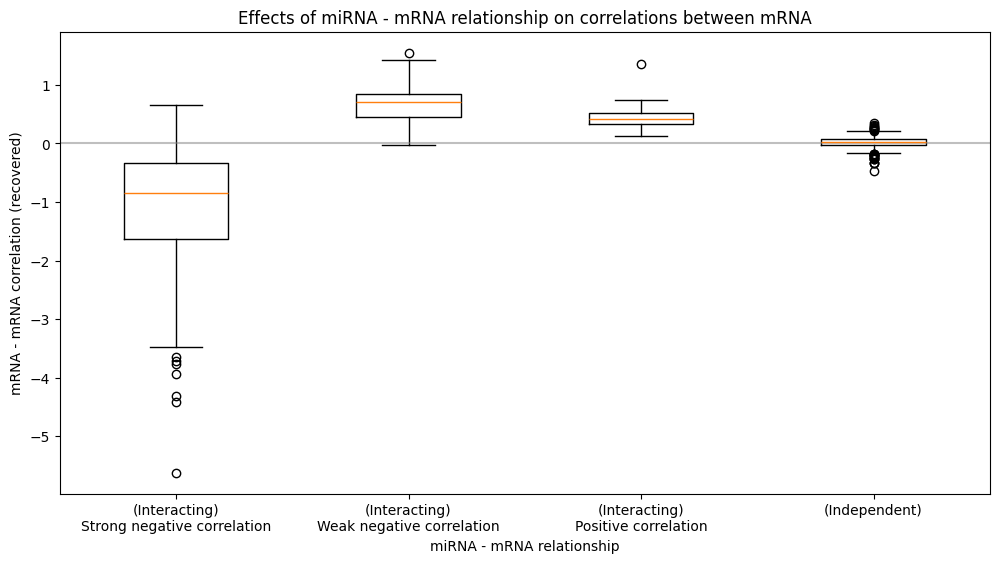

In [96]:
fig, axs = plt.subplots(figsize=(12, 6))
axs.boxplot([AL_corrs_strong, AL_corrs_weak, AL_corrs_pos, AL_corrs_unc], positions=[0, 1, 2, 3])
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticklabels(["(Interacting)\nStrong negative correlation", "(Interacting)\nWeak negative correlation", "(Interacting)\nPositive correlation", "(Independent)"])
axs.set_xlabel("miRNA - mRNA relationship")
axs.set_ylabel("mRNA - mRNA correlation (recovered)")
axs.set_title("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.show()

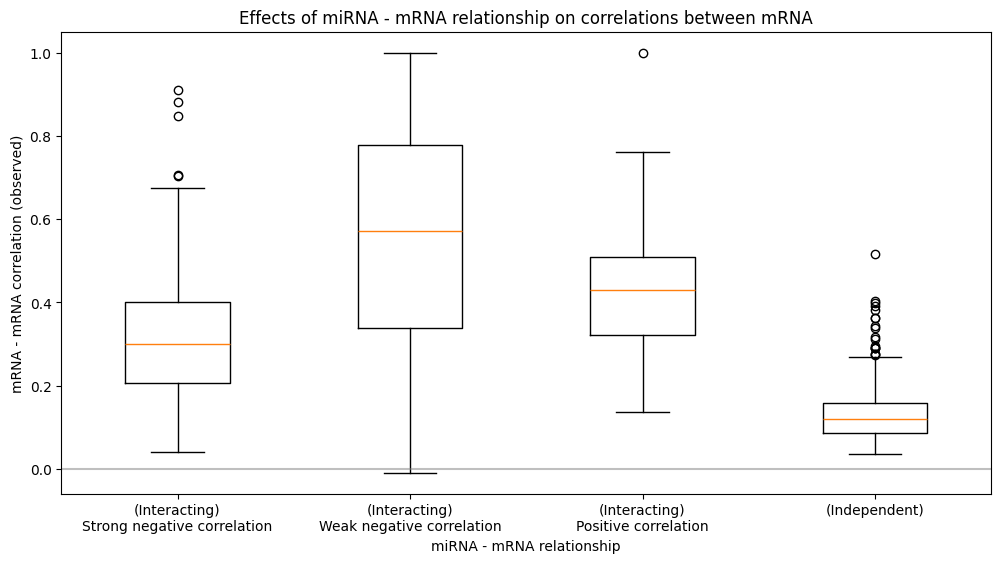

In [97]:
fig, axs = plt.subplots(figsize=(12, 6))
axs.boxplot([corrs_strong, corrs_weak, corrs_pos, corrs_unc], positions=[0, 1, 2, 3])
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticklabels(["(Interacting)\nStrong negative correlation", "(Interacting)\nWeak negative correlation", "(Interacting)\nPositive correlation", "(Independent)"])
axs.set_xlabel("miRNA - mRNA relationship")
axs.set_ylabel("mRNA - mRNA correlation (observed)")
axs.set_title("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.show()

## Telegraph infeasibility investigation

In [90]:
TE_40_df_NB

,MIR222_d3_c95_status
CAPZA1,TIME_LIMIT
TBCA,INFEASIBLE
YWHAE,INFEASIBLE
RPS28,INFEASIBLE
PDCD5,TIME_LIMIT
ATP5F1E,INFEASIBLE


In [104]:
adata_pcRNA.var[adata_pcRNA.var['GeneName'] == "TBCA"]

,gene_ids,feature_types,genome,GeneName,gene_id,biotype
11246,ENSG00000171530,Gene Expression,GRCh38,TBCA,ENSG00000171530,protein_coding


In [110]:
np.arange(10307)[adata_pcRNA.var.index == "11246"]

array([2898])

In [112]:
adata_pcRNA[:, 2898].var

,gene_ids,feature_types,genome,GeneName,gene_id,biotype
11246,ENSG00000171530,Gene Expression,GRCh38,TBCA,ENSG00000171530,protein_coding


In [118]:
import matplotlib.pyplot as plt

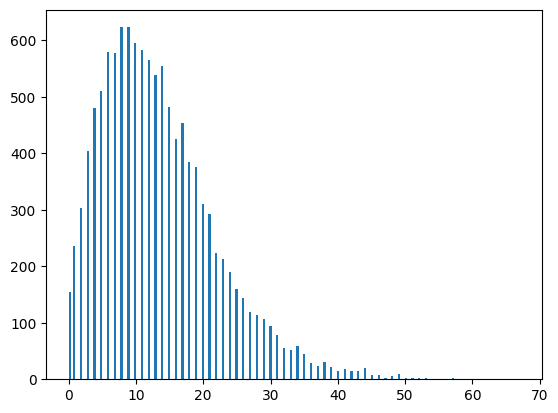

In [127]:
plt.hist(adata_pcRNA[:, 2898].X.toarray().squeeze(), bins=200);

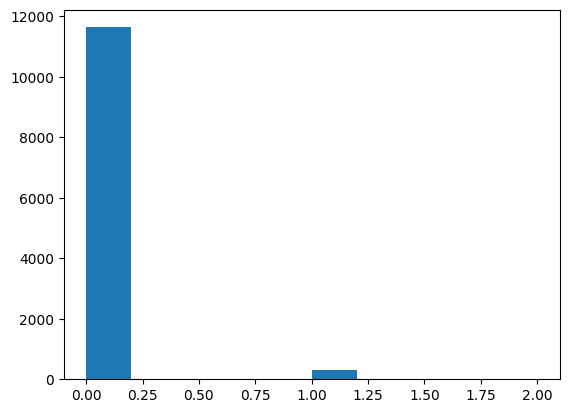

In [130]:
plt.hist(adata_miRNA[:, 40].X.toarray().squeeze());

## New package testing

In [3]:
import anndata as ad
import numpy as np
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation

In [4]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

In [8]:
#construct dataset
data = SDP_miRNA.dataset.Dataset()
data.construct_dataset_adata(
    adata_miRNA[:, 5],
    adata_pcRNA,
    beta
)

In [9]:
# bootstrap
data.bootstrap(d=3)

100%|██████████| 104/104 [03:08<00:00,  1.81s/it]


### MF ind

In [12]:
# model free independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data, d=3)
MF_ind.analyse_dataset()

100%|██████████| 10307/10307 [06:46<00:00, 25.38it/s]


In [41]:
# extract status
status_ind = np.array([res['status'] for res in MF_ind.result_dict.values()])

# display
np.unique(status_ind, return_counts=True)

(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([2432, 7875]))

### MF int

In [42]:
# select indices of interacting pairs
int_idxs = np.arange(status_ind.size)[status == "INFEASIBLE"]

In [67]:
# reduce gene queries
gene_queries = [
    [[0], [int(i)]] for i in int_idxs
]

# update dataset
data.gene_queries = gene_queries
data.total_gene_queries = len(gene_queries)

In [ ]:
# model free interacting: H&R
MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data, d=3)
MF_int.analyse_dataset()

### BD int (old)

In [68]:
data.total_gene_queries

2432

- try K = None instead of np.inf?
- try with nothing else open

In [44]:
# (old) interacting birth death
BD_int = SDP_miRNA.optimization.BirthDeathOptimization(data, d=3, time_limit=30, total_time_limit=30)
BD_int.analyse_dataset()

100%|██████████| 2432/2432 [26:36<00:00,  1.52it/s]  


In [ ]:
# (old) interacting birth death
BD_int_K = SDP_miRNA.optimization.BirthDeathOptimization(data, d=3, time_limit=30, total_time_limit=30, K=None)
BD_int_K.analyse_dataset()

In [47]:
# extract status
status_BD = np.array([res['status'] for res in BD_int.result_dict.values()])

# display
np.unique(status_BD, return_counts=True)

(array(['INFEASIBLE', 'OPTIMAL', 'TIME_LIMIT'], dtype='<U10'),
 array([1129, 1260,   43]))

In [50]:
# 1129 roughly same infeasibility as old code run, expect all to be feasible under telegraph
# time limits caused slowdown

### TE int (old)

### Correlation

In [51]:
# reset gene queries
gene_queries = [
    [[0], [int(i)]] for i in range(adata_pcRNA.n_vars)
]

# update dataset
data.gene_queries = gene_queries
data.total_gene_queries = len(gene_queries)

In [53]:
# OB & AL estimates: point and interval
OB_corrs, AL_corrs = SDP_miRNA.correlation.compute_correlations(data)

  1%|          | 1/104 [00:02<04:13,  2.47s/it]c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
100%|██████████| 104/104 [01:25<00:00,  1.21it/s]


In [57]:
import matplotlib.pyplot as plt

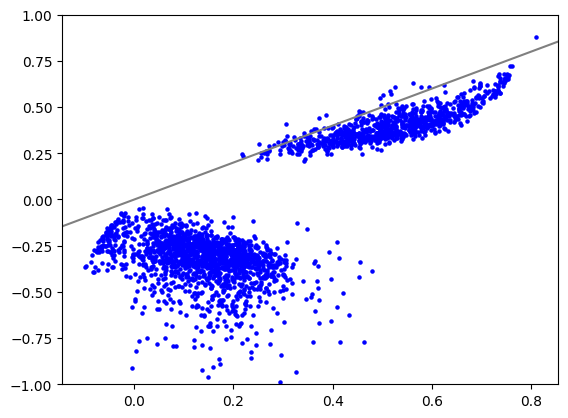

In [66]:
plt.scatter(OB_corrs[int_idxs, 0], AL_corrs[int_idxs, 0], s=5, color="blue")
plt.ylim(bottom=-1, top=1)
plt.axline([0]*2, [0.1]*2, color="grey")